<a href="https://colab.research.google.com/github/alexaK88/Q_jpeg_pennylane/blob/main/QEK_training_Hinge_AdamOptimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane
!pip install pennylane pennylane-lightning[gpu]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.5/366.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 

### Import Libraries

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane.templates import QFT
from sklearn.svm import SVC
from sklearn.datasets import fetch_openml, load_digits
from sklearn.preprocessing import MinMaxScaler, normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from pennylane import numpy as pnp
from skimage.transform import resize
from keras.datasets import mnist

### Dataset Preparation


First, we load the MNIST dataset from openML.
- X is the pixel data
- y is the labels
- converting everything to `uint8` here to ensure all values are integers in [0, 255]

In [3]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(np.uint8) # better to convert for binerization
y = y.astype(np.uint8)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Next, we focus on 2 classes, i.e. binary classification.
Here, I've been experimenting with different classes, and I stopped on 4 vs 9, cause they have more subtle difference in pixels, they are similar looking.

In [4]:
# focus on binary classification
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]
X.shape

(14780, 28, 28)

- I take only the first `n_samples`.
- I convert X to a NumPy array, and shuffling the data randomly

In [5]:
n_samples = 200 # restricting to 6000 samples for now

X = X.values if hasattr(X, "values") else X # safer conversion

X = X[:n_samples]
y = y[:n_samples]

Now, I normalise pixel intensities.
- [0, 255] -> [0, 1]
- reshaping images back to 2D for resizing, i.e to 28x28 array with float values between 0 and 1.

In [6]:
X = X / 255.0
X = X.reshape(-1, 28, 28)

y = 2 * y - 1 # KTA requires labels in {-1, 1}

print(X.shape)
print("Pixel range:", X.min(), X.max())

(200, 28, 28)
Pixel range: 0.0 1.0


And now I reduce images to 8x8 + flattening to (, 64)
- resize -> flatten -> normalize

In [7]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=False,
        preserve_range=True,
        order=1 # controlling interpolation
    )
    img_8x8 = img_8x8.flatten().astype(float)
    img_8x8 -= img_8x8.mean()
    norm = np.linalg.norm(img_8x8)
    if norm > 0:
        img_8x8 /= norm
    else:
        img_8x8[0] = 1.0
      # should be shape (64,)
    return img_8x8

# apply transformation to all images
X_8x8 = np.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(200, 64)

In [8]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", np.isnan(X_8x8).any())
print("Norm check:", np.min(np.linalg.norm(X_8x8, axis=1)), np.max(np.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999998 1.0000000000000002


I'm gonna do the splitting here, and carry both representations consistently.
- qek inputs: (64,) flattened and normalized vectors, for quantum kernel embedding
- qjpeg: 28x28 images

In [9]:
idx = np.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

# QEK inputs (8x8 -> 64 -> normed)
X_train_qek = X_8x8[idx_train]
X_test_qek  = X_8x8[idx_test]

# QJPEG inputs (28x28 binary images)
X_train_img = X[idx_train]
X_test_img  = X[idx_test]

print("QEK train/test:", X_train_qek.shape, X_test_qek.shape)
print("IMG train/test:", X_train_img.shape, X_test_img.shape)
print("Labels train/test:", y_train.shape, y_test.shape)

QEK train/test: (160, 64) (40, 64)
IMG train/test: (160, 28, 28) (40, 28, 28)
Labels train/test: (160,) (40,)


Data preparation is done.

### Quantum Embedding & Kernel Training

Define number of qubits and device.

In [10]:
device = "default.qubit"
n_qubits = 6

In [11]:
dev = qml.device(device, wires=n_qubits, shots=None)

Defining the parametrised quantum circuit:

In [12]:
# def quantum_circuit(x, theta):
#     # Trainable block FIRST
#     for l in range(theta.shape[0]):

#         for q in range(n_qubits):
#             qml.RY(theta[l, q, 0], wires=q)
#             qml.RZ(theta[l, q, 1], wires=q)

#         for q in range(n_qubits - 1):
#             qml.CNOT(wires=[q, q + 1])

#         for q in range(n_qubits - 1):
#             qml.CNOT(wires=[q + 1, q])

#     # Data embedding
#     qml.AmplitudeEmbedding(
#         x,
#         wires=range(n_qubits),
#         normalize=False
#     )

# @qml.qnode(dev, diff_method="backprop")
# def qek_kernel(x1, x2, theta):
#     quantum_circuit(x1, theta)
#     qml.adjoint(quantum_circuit)(x2, theta)
#     return qml.expval(qml.Projector([0]*n_qubits, wires=range(n_qubits)))

def qek_layer_amplitude(x, theta_l):
    # Data re-uploading via phase gates (breaks kernel symmetry)
    for q in range(n_qubits):
        qml.RZ(np.pi * x[q], wires=q)

    # Trainable block
    for q in range(n_qubits):
        qml.RX(theta_l[q, 0], wires=q)
        qml.RZ(theta_l[q, 1], wires=q)

    # Entanglement (non-commuting)
    for q in range(n_qubits - 1):
        qml.CNOT(wires=[q, q + 1])

def qek_embedding_amplitude(x, theta):
    qml.AmplitudeEmbedding(
        x,
        wires=range(n_qubits),
        normalize=True
    )

    for l in range(theta.shape[0]):
        qek_layer_amplitude(x, theta[l])

# quantum circuit
@qml.qnode(dev, diff_method="backprop")
def qek_kernel(x1, x2, theta):
    qek_embedding_amplitude(x1, theta)
    qml.adjoint(qek_embedding_amplitude)(x2, theta)
    return qml.expval(qml.Projector([0]*n_qubits, wires=range(n_qubits)))


def kernel_hinge_loss(theta, alpha, X, y, C=1.0):

    K = qml.kernels.square_kernel_matrix(
        X,
        lambda x1, x2: qek_kernel(x1, x2, theta)
    )
    f = K @ (alpha * y)

    margins = y * f

    zeros = qml.math.zeros_like(margins)
    ones  = qml.math.ones_like(margins)

    hinge = qml.math.mean(
        qml.math.maximum(zeros, ones - margins) ** 2
    )

    alpha = qml.math.clip(alpha, 0.0, C)
    reg = 0.5 * qml.math.sum(alpha**2)

    return reg + C * hinge

In [13]:
n_features = n_qubits
w = 0.01 * pnp.random.randn(n_features, requires_grad=True)
b = pnp.array(0.0, requires_grad=True)

In [14]:
n_layers = 4
n_steps = 300
batch_size = 32
stepsize = 5e-3
beta1 = 0.7
beta2 = 0.85

subset_train = 50
subset_test  = 50

X_train_subset = X_train_qek[:subset_train]
y_train_subset = y_train[:subset_train]

theta = 0.3 * pnp.random.randn(n_layers, n_qubits, 2)
alpha = 0.01 * pnp.random.randn(
    len(X_train_qek),
    requires_grad=True
)
opt = qml.AdamOptimizer(stepsize=stepsize, beta1=beta1, beta2=beta2)

ema = None

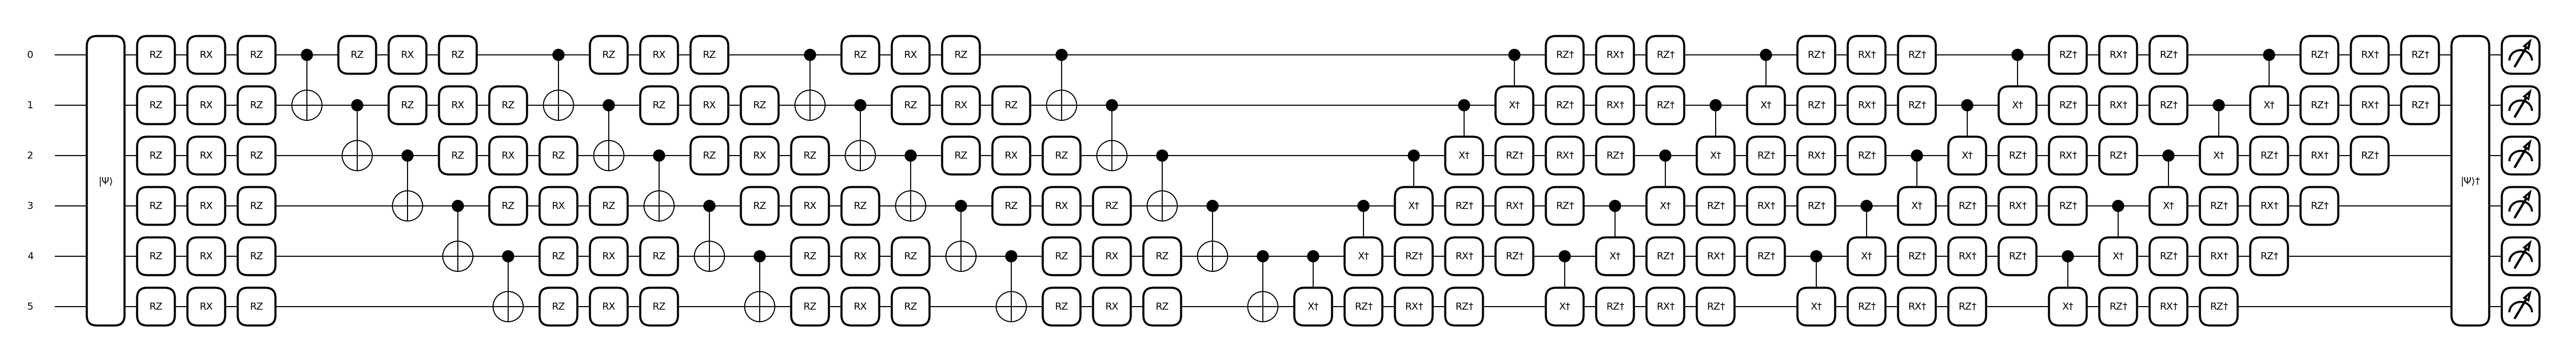

In [15]:
fig, ax = qml.draw_mpl(qek_kernel)(X_train_subset[0], X_train_subset[0], theta)
fig.show()

In [ ]:
for step in range(n_steps):

    idx = np.random.choice(len(X_train_qek), batch_size, replace=False)

    X_batch = X_train_qek[idx]
    y_batch = y_train[idx]
    alpha_batch = alpha[idx]

    theta, alpha_batch = opt.step(
        lambda th, a: kernel_hinge_loss(th, a, X_batch, y_batch),
        theta, alpha_batch
    )

    # write back updated alphas
    alpha[idx] = alpha_batch

    if step % 20 == 0:

        # Recompute loss OUTSIDE gradient trace
        loss_val = kernel_hinge_loss(
            theta, alpha, X_train_qek, y_train
        )

        print(f"Step {step} | loss={loss_val}")


Step 0 | loss=2749025.09220135
Step 20 | loss=74930499.72925545
Step 40 | loss=118759426.92688018
Step 60 | loss=130178128.64885435
Step 80 | loss=130993384.47128662
Step 100 | loss=130994706.1474379
Step 120 | loss=130994717.08561246
Step 140 | loss=130994717.09362292
